<a href="https://colab.research.google.com/github/Ostap-Tyndyk/Sales-analysis/blob/main/Global_sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Changing work folder
%cd /content/drive/MyDrive/Mate_projects

/content/drive/MyDrive/Mate_projects


In [ ]:
countries_data = pd.read_csv("countries.csv")
events_data = pd.read_csv("events.csv")
products_data = pd.read_csv("products.csv")
print("countries_data info:")
print(countries_data.info())

print("events_data info:")
print(events_data.info())

print("products_data info:")
print(products_data.info())
print(countries_data.head())
print(events_data.head())
print(products_data.head())

countries_data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None
events_data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold     

- *Датасет **countries** має 249 рядків та 5 стовпців, містить трошки пропущених значень в деяких стовпцях. Стовпці містять країну, скорочений запис 2 варіанти, регіон і субрегіон.*
- *Датасет **events** має 1330 рядків, 10 стовпців 2 пропущені значення в untis_sold і велику кількість пропущених значень в country code. Стовпці містять ID замовлення, дата замовленння, дата прибуття, пріоритет замовлення, код країни, ID продукту, канал продажів, кількість проданих одиниць , ціна за одиницю, витрати на одиницю*.
- *Датасет **products** має 12 рядків і 2 стовпці, пропущених значень немає, типи даних правильні. Стовпці містять ID продукту і категорію продукту*.

**Ключові поля, що поєднують таблиці:** countries - alpha-3 => events - Country Code, events Product ID => product - id

In [ ]:
countries_nulls = countries_data.isna().sum()
print(f"Пропущені значення в countries:\n{countries_nulls}")
events_nulls = events_data.isna().sum()
print(f"\nПропущені значення в events:\n{events_nulls}")

Пропущені значення в countries:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

Пропущені значення в events:
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
countries_data = countries_data.dropna()
events_data["Country Code"] = events_data["Country Code"].fillna("Unknown")
events_data = events_data.dropna(subset = "Units Sold")

*В датасеті **countries** було видалено всі рядки з пропущеними значеннями, оскільки таких пропущених значень було мало. В датасеті **events** було видалено 2 рядки, де пропущено Units Sold, оскільки також це невелика кількість, в Country Code ж було виявлено багато пропущених значень, тому щоб не втрачати дані, ці пропущені значення були замінені на "**Unknown**". В датасеті **products** пропущених значень немає, тому з ним працювати не прийшлося.*

In [ ]:
# Перетворення колонок з датою в тип datetime
events_data["Order Date"] = pd.to_datetime(events_data["Order Date"])
events_data["Ship Date"] = pd.to_datetime(events_data["Ship Date"])

In [ ]:
events_duplicates = events_data.duplicated().sum()
print(events_duplicates)

countries_duplicates = countries_data.duplicated().sum()
print(countries_duplicates)

products_duplicates = products_data.duplicated().sum()
print(products_duplicates)


0
0
0


*В кожному датасеті дублікати не виявлені.*

In [ ]:
print("Events metrcics:")
events_data.describe()

Events metrcics:


,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


*Порівнюючи середнє значення з медіаною можна побачити що в кількості проданих одиниць середнє значення і медіана приблизно рівні. В ціні за одиницю(mean = 264, median = 154) середнє значення на 110 більше за медіану і у вартості за одиницю(mean = 187, median = 97) середнє значення на 90 більше, що означає, що в ціні та вартості за одиницю є частка дуже великих значень, яка доволі суттєво збільшує середнє значення.*

In [ ]:
# З'єднання в 1 датафрейм
sales_data = pd.merge(events_data, countries_data, left_on = "Country Code", right_on = "alpha-3", how = "left")
sales_data = pd.merge(sales_data, products_data, left_on = "Product ID", right_on = "id", how = "left")
sales_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,NaN,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,1270,Beverages


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
 10  name            1246 non-null   object        
 11  alpha-2         1246 non-null   object        
 12  alpha-3         1246 non-null   object        
 13  region          1246 non-null   object        
 14  sub-region      1246 non-null   object        
 15  id  

In [ ]:
# Видалення непотрібних колонок id для аналізу
sales_data = sales_data.drop(columns = ["Order ID", "Product ID", "id"])
sales_data.head()

,Order Date,Ship Date,Order Priority,Country Code,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region,item_type
0,2014-10-08,2014-10-18,M,NOR,Online,650.0,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,Cereal
1,2016-08-11,2016-08-11,C,SRB,Offline,1993.0,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,Cereal
2,2014-07-18,2014-08-11,M,Unknown,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,NaN,Household
3,2017-05-13,2017-06-13,L,MNE,Online,1171.0,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,Clothes
4,2012-08-11,2012-09-18,H,SRB,Offline,7648.0,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,Beverages


In [ ]:
# Перейменування назв колонок в стиль snake_case
sales_data.columns = sales_data.columns.str.lower().str.replace(" ", "_")
sales_data.head()

,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,name,alpha-2,alpha-3,region,sub-region,item_type
0,2014-10-08,2014-10-18,M,NOR,Online,650.0,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,Cereal
1,2016-08-11,2016-08-11,C,SRB,Offline,1993.0,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,Cereal
2,2014-07-18,2014-08-11,M,Unknown,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,NaN,Household
3,2017-05-13,2017-06-13,L,MNE,Online,1171.0,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,Clothes
4,2012-08-11,2012-09-18,H,SRB,Offline,7648.0,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,Beverages


In [ ]:
# Ключові метрики
total_revenue = (sales_data["units_sold"] * sales_data["unit_price"]).sum()
total_cost = (sales_data["units_sold"] * sales_data["unit_cost"]).sum()
total_profit = total_revenue - total_cost
total_countries = sales_data["name"].nunique()
max_deliver_days = (sales_data["ship_date"] - sales_data["order_date"]).max().days
min_deliver_days = (sales_data["ship_date"] - sales_data["order_date"]).min().days


print(f"Загальна кількість замовлень: {len(sales_data)}")
print(f"Загальна кількість проданих одиниць: {sales_data["units_sold"].sum()}")
print(f"Загальний виторг: ${total_revenue}")
print(f"Загальні витрати: ${total_cost}")
print(f"Загальний прибуток: ${total_profit}")
print(f"Загальна кількість охоплених країн: {total_countries}")
print(f"Максимальна кількість днів доставки: {max_deliver_days}")
print(f"Мінімальна кількість днів доставки: {min_deliver_days}")


Загальна кількість замовлень: 1328
Загальна кількість проданих одиниць: 6576524.0
Загальний виторг: $1702129408.21
Загальні витрати: $1200694949.21
Загальний прибуток: $501434459.0
Загальна кількість охоплених країн: 45
Максимальна кількість днів доставки: 50
Мінімальна кількість днів доставки: 0


In [ ]:
# Додавання необхідних колонок для візуалізації
sales_data["revenue"] = sales_data["units_sold"] * sales_data["unit_price"]
sales_data["cost"] = sales_data["units_sold"] * sales_data["unit_cost"]
sales_data["profit"] = sales_data["revenue"] - sales_data["cost"]
sales_data.head()

,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,name,alpha-2,alpha-3,region,sub-region,item_type,revenue,cost,profit
0,2014-10-08,2014-10-18,M,NOR,Online,650.0,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50
1,2016-08-11,2016-08-11,C,SRB,Offline,1993.0,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87
2,2014-07-18,2014-08-11,M,Unknown,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,NaN,Household,3136191.11,2358420.22,777770.89
3,2017-05-13,2017-06-13,L,MNE,Online,1171.0,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24
4,2012-08-11,2012-09-18,H,SRB,Offline,7648.0,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68


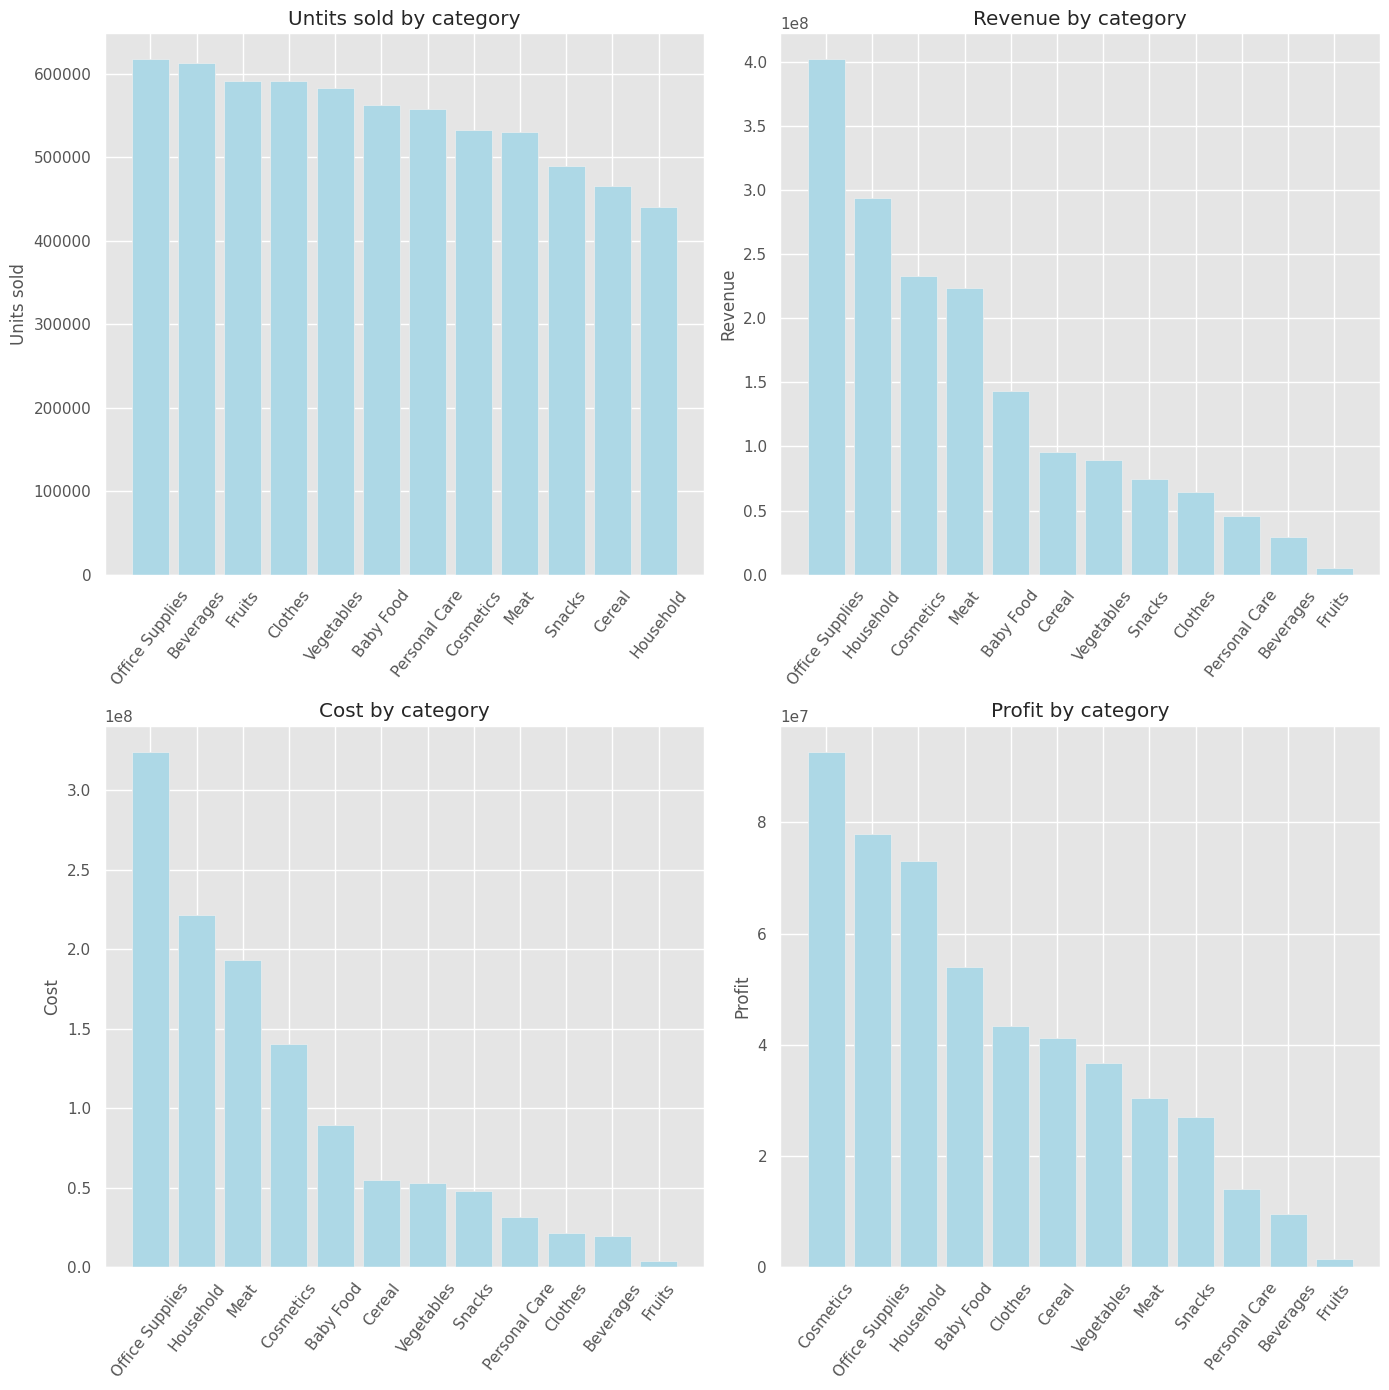

In [ ]:

# Стиль
plt.style.use('ggplot')
# Метрики - доходи, витрати, прибутки, популярність товарів
fig, ax = plt.subplots(2, 2, figsize = (14, 14))

# Візуалізація по категоріях Units sold
units_sold_grouped = sales_data.groupby("item_type")["units_sold"].sum().sort_values(ascending = False)
ax[0, 0].bar(units_sold_grouped.index, units_sold_grouped.values, color = "lightblue")
ax[0, 0].tick_params(axis = "x", rotation = 52)
ax[0, 0].set_title("Untits sold by category")
ax[0, 0].set_ylabel("Units sold")

# Візуалізація по категоріях Revenue
revenue_grouped = sales_data.groupby("item_type")["revenue"].sum().sort_values(ascending = False)
ax[0, 1].bar(revenue_grouped.index, revenue_grouped.values, color = "lightblue")
ax[0, 1].tick_params(axis = "x", rotation = 52)
ax[0, 1].set_title("Revenue by category")
ax[0, 1].set_ylabel("Revenue")

# Візуалізація по категоріях Cost
cost_grouped = sales_data.groupby("item_type")["cost"].sum().sort_values(ascending = False)
ax[1, 0].bar(cost_grouped.index, cost_grouped.values, color = "lightblue")
ax[1, 0].tick_params(axis = "x", rotation = 52)
ax[1, 0].set_title("Cost by category")
ax[1, 0].set_ylabel("Cost")

# Візуалізація по категоріях Profit
profit_grouped = sales_data.groupby("item_type")["profit"].sum().sort_values(ascending = False)
ax[1, 1].bar(profit_grouped.index, profit_grouped.values, color = "lightblue")
ax[1, 1].tick_params(axis = "x", rotation = 52)
ax[1, 1].set_title("Profit by category")
ax[1, 1].set_ylabel("Profit")


plt.tight_layout()
plt.show()

*Найприбутковіша категорія - Cosmetics, найбільша вартість - Office Supplies.Також категорія Clothes одна з найпоулярніших по кількості проданих одиниць, але по прибутку знаходиться посередині.*

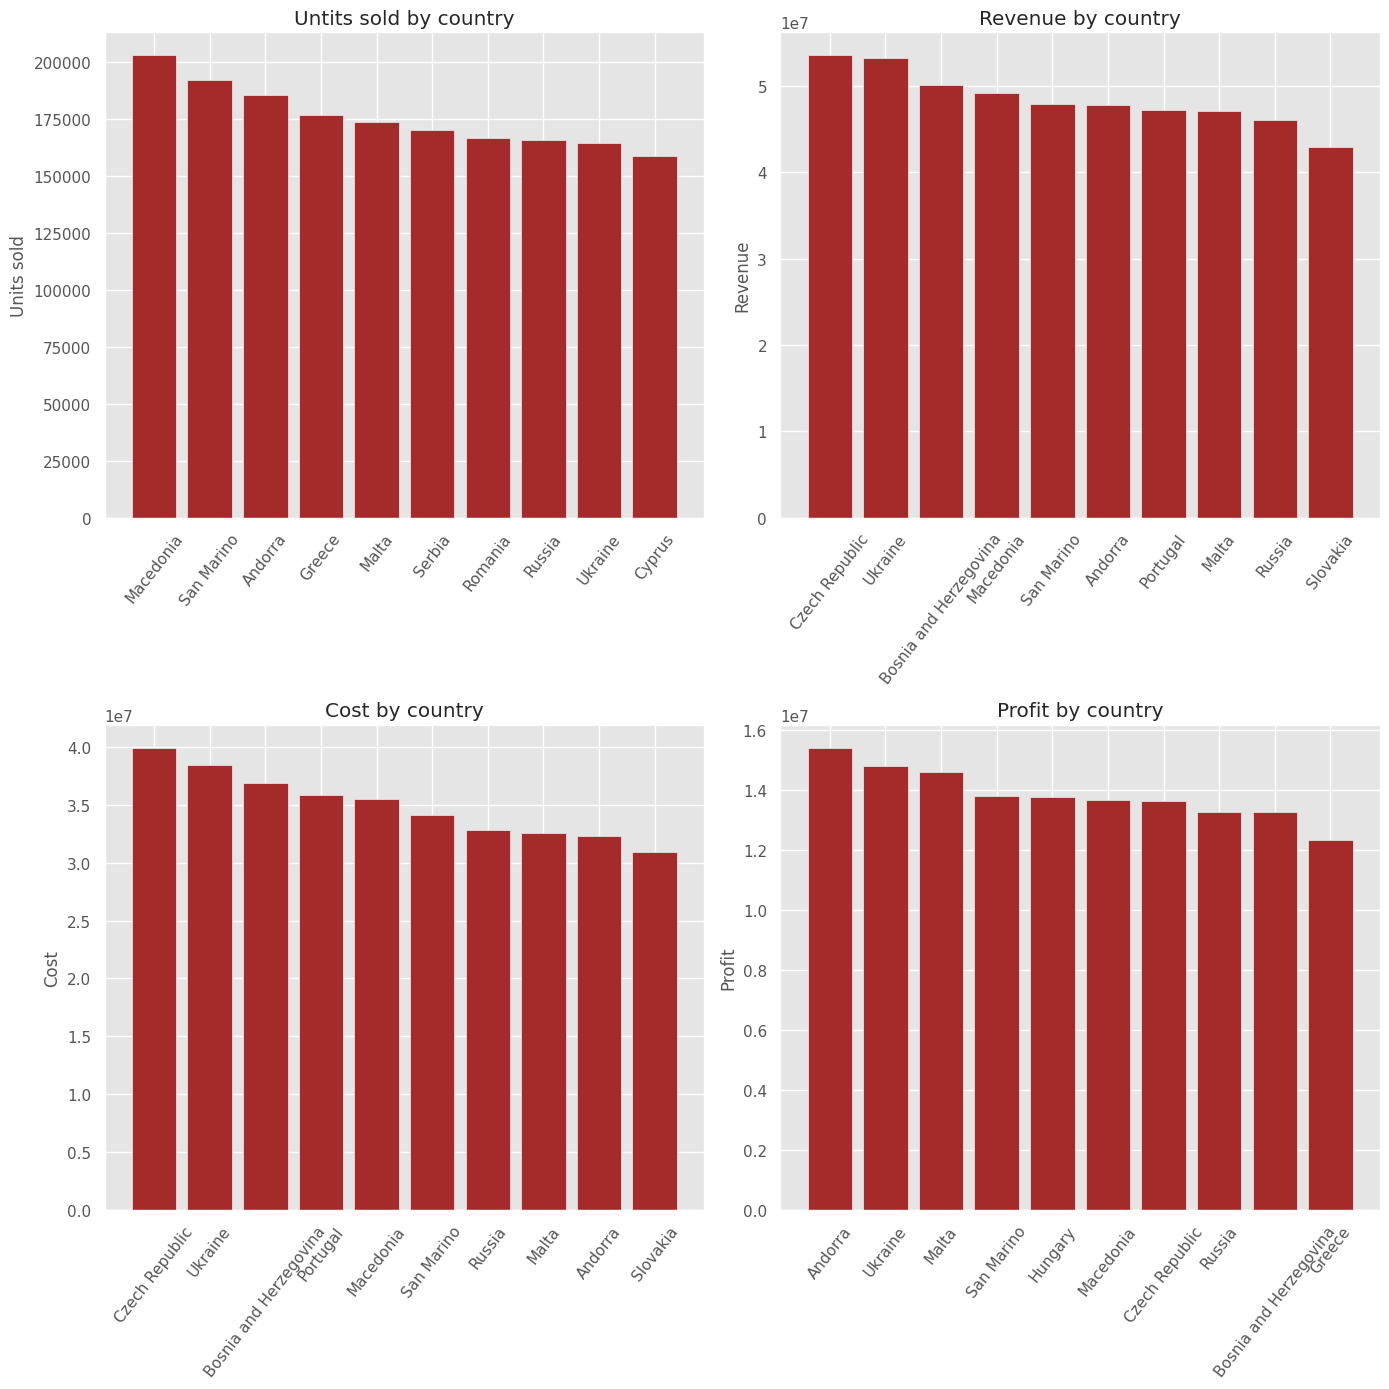

In [ ]:

# Стиль
plt.style.use('ggplot')
# Метрики - доходи, витрати, прибутки, популярність товарів
fig, ax = plt.subplots(2, 2, figsize = (14, 14))

# Візуалізація по категоріях Units sold
units_sold_grouped = sales_data.groupby("name")["units_sold"].sum().sort_values(ascending = False).head(10)
ax[0, 0].bar(units_sold_grouped.index, units_sold_grouped.values, color = "brown")
ax[0, 0].tick_params(axis = "x", rotation = 52)
ax[0, 0].set_title("Untits sold by country")
ax[0, 0].set_ylabel("Units sold")

# Візуалізація по країнах Revenue
revenue_grouped = sales_data.groupby("name")["revenue"].sum().sort_values(ascending = False).head(10)
ax[0, 1].bar(revenue_grouped.index, revenue_grouped.values, color = "brown")
ax[0, 1].tick_params(axis = "x", rotation = 52)
ax[0, 1].set_title("Revenue by country")
ax[0, 1].set_ylabel("Revenue")

# Візуалізація по категоріях Cost
cost_grouped = sales_data.groupby("name")["cost"].sum().sort_values(ascending = False).head(10)
ax[1, 0].bar(cost_grouped.index, cost_grouped.values, color = "brown")
ax[1, 0].tick_params(axis = "x", rotation = 52)
ax[1, 0].set_title("Cost by country")
ax[1, 0].set_ylabel("Cost")

# Візуалізація по категоріях Profit
profit_grouped = sales_data.groupby("name")["profit"].sum().sort_values(ascending = False).head(10)
ax[1, 1].bar(profit_grouped.index, profit_grouped.values, color = "brown")
ax[1, 1].tick_params(axis = "x", rotation = 52)
ax[1, 1].set_title("Profit by country")
ax[1, 1].set_ylabel("Profit")


plt.tight_layout()
plt.show()

*Найбільша кількість одиниць продажу в Македонії, а найбільший прибуток від Андори. Загалом в топ 10 країнах доволі рівні значення всіх показників.*

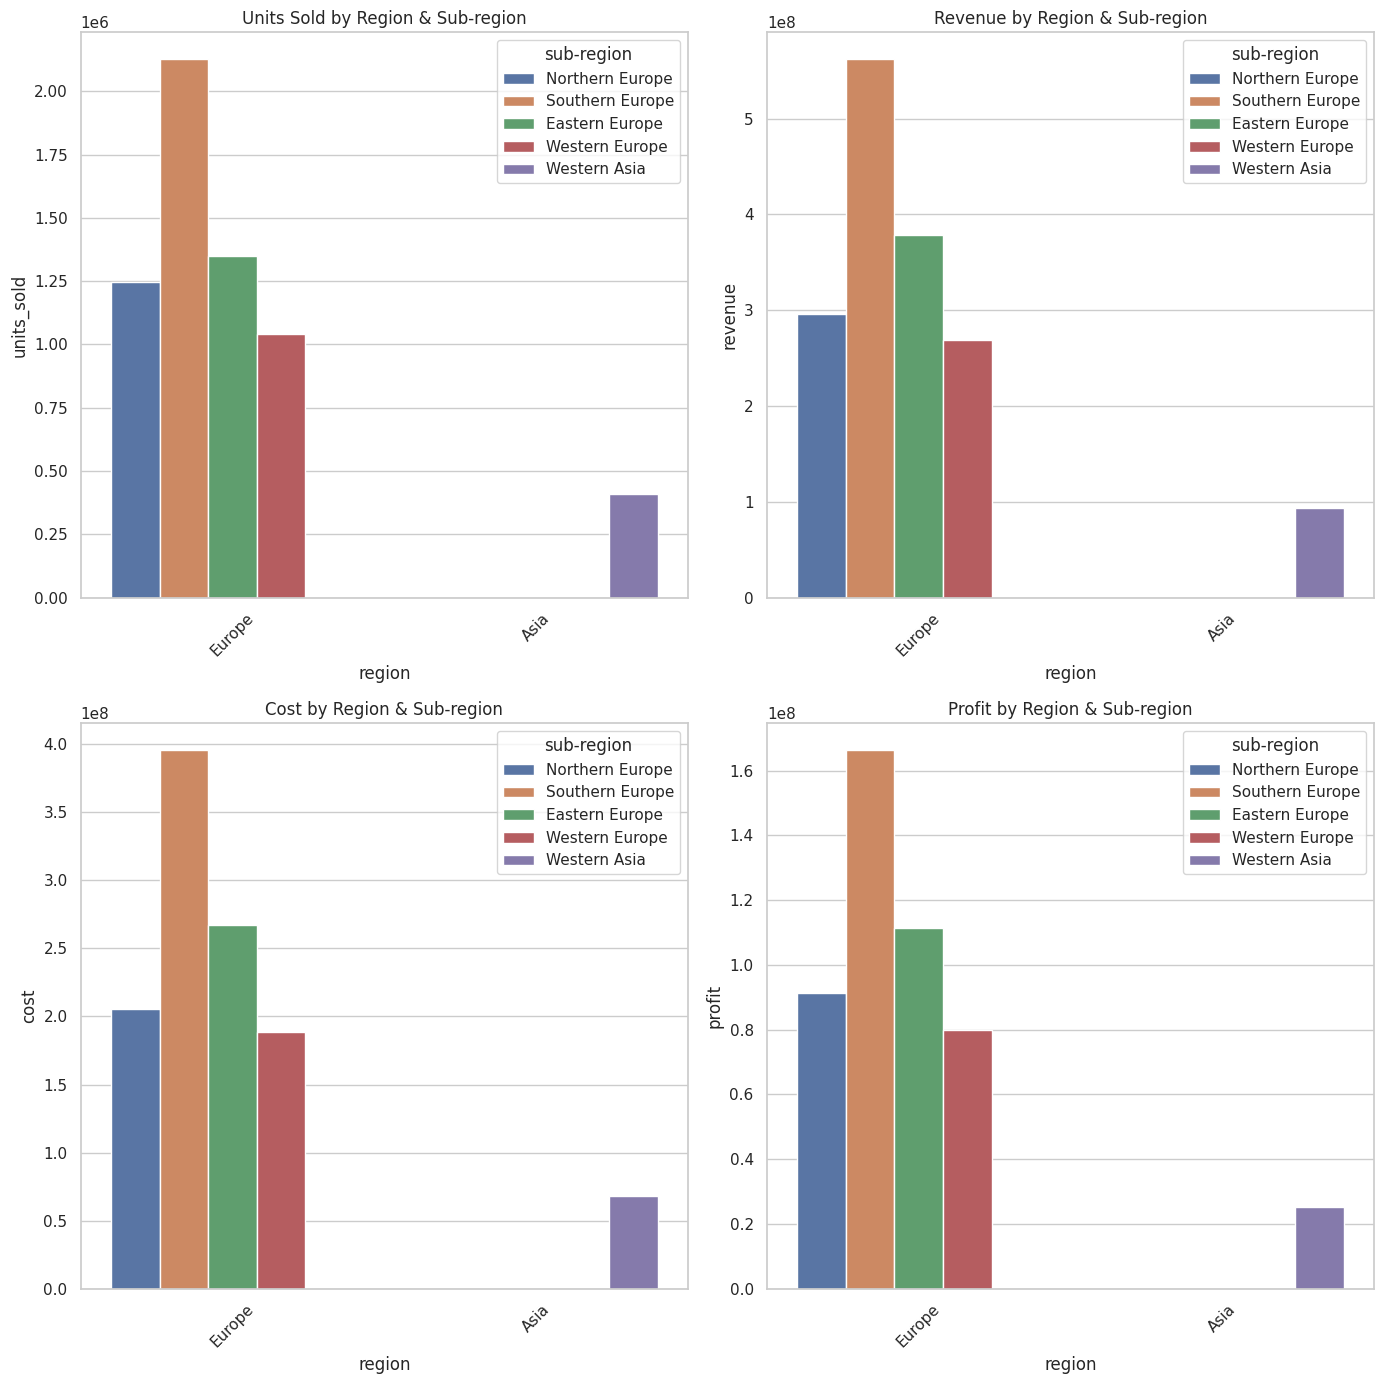

In [ ]:
# Налаштування загального стилю
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(2, 2, figsize=(14, 14))

# Візуалізація по регіонах Units sold
sns.barplot(data=sales_data, x="region", y="units_sold", hue="sub-region",
            estimator=sum, errorbar=None, ax=ax[0, 0])
ax[0, 0].set_title("Units Sold by Region & Sub-region")
ax[0, 0].tick_params(axis="x", rotation=45)

# Візуалізація по регіонах revenue
sns.barplot(data=sales_data, x="region", y="revenue", hue="sub-region",
            estimator=sum, errorbar=None, ax=ax[0, 1])
ax[0, 1].set_title("Revenue by Region & Sub-region")
ax[0, 1].tick_params(axis="x", rotation=45)

# Візуалізація по регіонах cost
sns.barplot(data=sales_data, x="region", y="cost", hue="sub-region",
            estimator=sum, errorbar=None, ax=ax[1, 0])
ax[1, 0].set_title("Cost by Region & Sub-region")
ax[1, 0].tick_params(axis="x", rotation=45)

# Візуалізація по регіонах profit
sns.barplot(data=sales_data, x="region", y="profit", hue="sub-region",
            estimator=sum, errorbar=None, ax=ax[1, 1])
ax[1, 1].set_title("Profit by Region & Sub-region")
ax[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

*Абсолютна більшість продажів в Європі, в Азії ж - дуже мала частка. Лідером серед Європи по всіх параметрах є Східна Європа.*

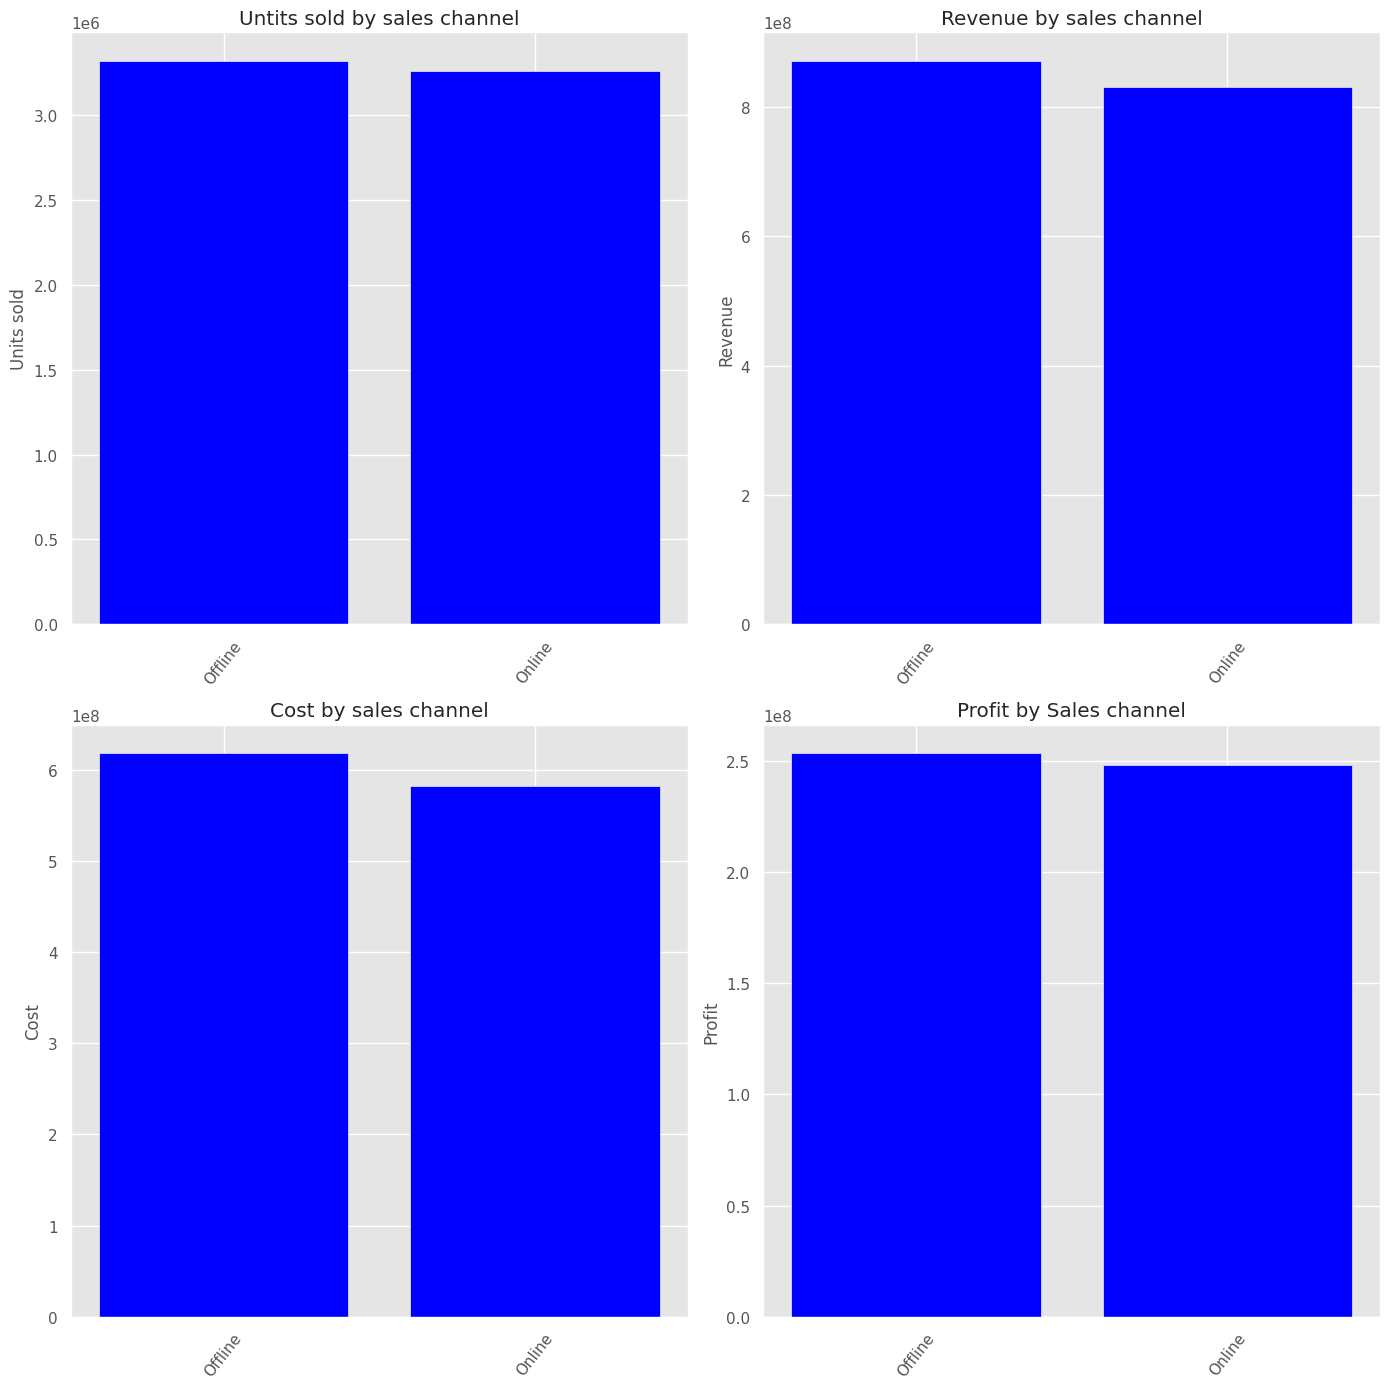

In [ ]:
# Щоб Online і online сприймався однаково
sales_data["sales_channel"] = sales_data["sales_channel"].str.title()

# Стиль
plt.style.use('ggplot')
# Метрики - доходи, витрати, прибутки, популярність товарів
fig, ax = plt.subplots(2, 2, figsize = (14, 14))

# Візуалізація по каналах продажу Units sold
units_sold_grouped = sales_data.groupby("sales_channel")["units_sold"].sum().sort_values(ascending = False)
ax[0, 0].bar(units_sold_grouped.index, units_sold_grouped.values, color = "blue")
ax[0, 0].tick_params(axis = "x", rotation = 52)
ax[0, 0].set_title("Untits sold by sales channel")
ax[0, 0].set_ylabel("Units sold")

# Візуалізація по каналах продажу revenue
revenue_grouped = sales_data.groupby("sales_channel")["revenue"].sum().sort_values(ascending = False)
ax[0, 1].bar(revenue_grouped.index, revenue_grouped.values, color = "blue")
ax[0, 1].tick_params(axis = "x", rotation = 52)
ax[0, 1].set_title("Revenue by sales channel")
ax[0, 1].set_ylabel("Revenue")

# Візуалізація по каналах продажу cost
cost_grouped = sales_data.groupby("sales_channel")["cost"].sum().sort_values(ascending = False)
ax[1, 0].bar(cost_grouped.index, cost_grouped.values, color = "blue")
ax[1, 0].tick_params(axis = "x", rotation = 52)
ax[1, 0].set_title("Cost by sales channel")
ax[1, 0].set_ylabel("Cost")

# Візуалізація по каналах продажу profit
profit_grouped = sales_data.groupby("sales_channel")["profit"].sum().sort_values(ascending = False)
ax[1, 1].bar(profit_grouped.index, profit_grouped.values, color = "blue")
ax[1, 1].tick_params(axis = "x", rotation = 52)
ax[1, 1].set_title("Profit by Sales channel")
ax[1, 1].set_ylabel("Profit")


plt.tight_layout()
plt.show()

*Для всіх показнків Online і Offline є майже рівними.*

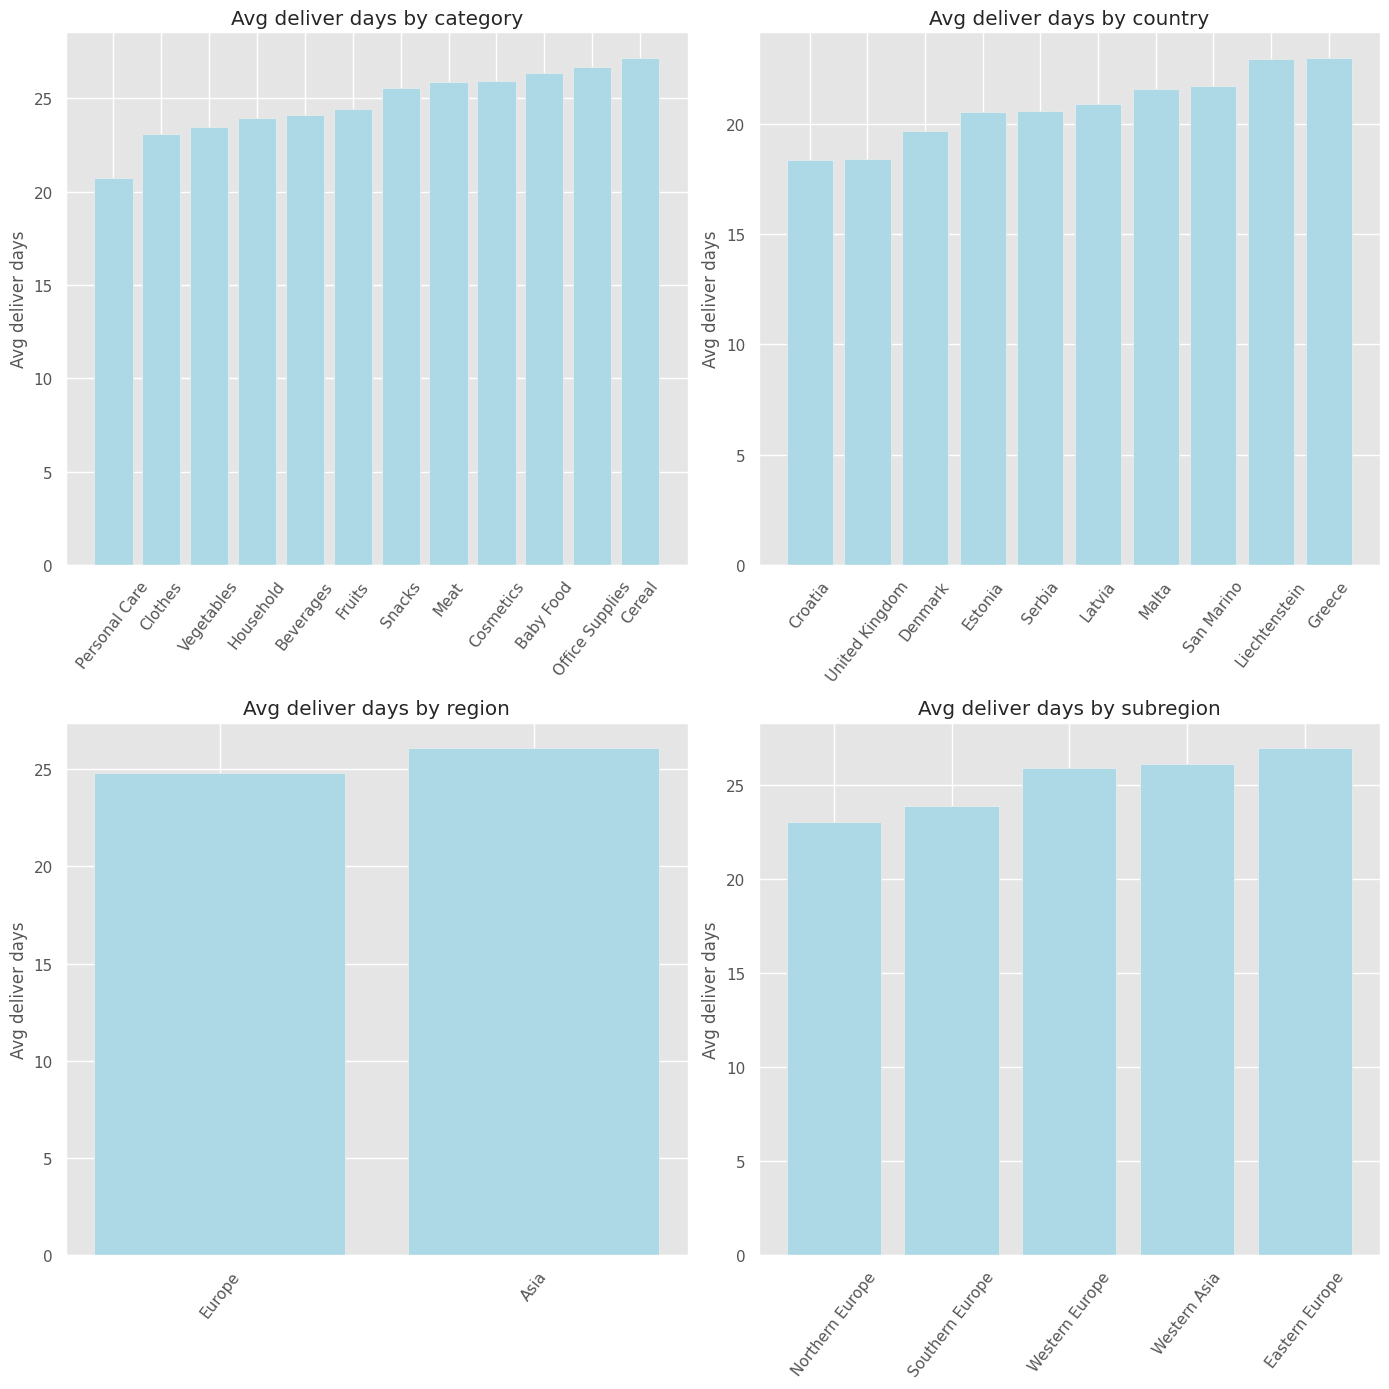

In [ ]:
# Додавання колонки deliver, щоб порахувати час доставки
sales_data["deliver"] = (sales_data["ship_date"] - sales_data["order_date"]).dt.days

# Стиль
plt.style.use('ggplot')
# Час доставки
fig, ax = plt.subplots(2, 2, figsize = (14, 14))

# Візуалізація по категоріях продажу час доставки
category_grouped = sales_data.groupby("item_type")["deliver"].mean().sort_values(ascending = True)
ax[0, 0].bar(category_grouped.index, category_grouped.values, color = "lightblue")
ax[0, 0].tick_params(axis = "x", rotation = 52)
ax[0, 0].set_title("Avg deliver days by category")
ax[0, 0].set_ylabel("Avg deliver days")

# Візуалізація по топ 10 країнах час доставки
country_grouped = sales_data.groupby("name")["deliver"].mean().sort_values(ascending = True).head(10)
ax[0, 1].bar(country_grouped.index, country_grouped.values, color = "lightblue")
ax[0, 1].tick_params(axis = "x", rotation = 52)
ax[0, 1].set_title("Avg deliver days by country")
ax[0, 1].set_ylabel("Avg deliver days")

# Візуалізація по регіонах час доставки
region_grouped = sales_data.groupby("region")["deliver"].mean().sort_values(ascending = True)
ax[1, 0].bar(region_grouped.index, region_grouped.values, color = "lightblue")
ax[1, 0].tick_params(axis = "x", rotation = 52)
ax[1, 0].set_title("Avg deliver days by region")
ax[1, 0].set_ylabel("Avg deliver days")

# Візуалізація по суб-регіонах час доставки
subregion_grouped = sales_data.groupby("sub-region")["deliver"].mean().sort_values(ascending = True)
ax[1, 1].bar(subregion_grouped.index, subregion_grouped.values, color = "lightblue")
ax[1, 1].tick_params(axis = "x", rotation = 52)
ax[1, 1].set_title("Avg deliver days by subregion")
ax[1, 1].set_ylabel("Avg deliver days")


plt.tight_layout()
plt.show()

*Найшвдиша середня доставка(21 день) проходить для категорії **Personal Care**. Серед країн найшвидше в Хорватії і Великобританії (21-22 дні). Для регіонів і субрегіонів середня доставка майже не відрізняється.*

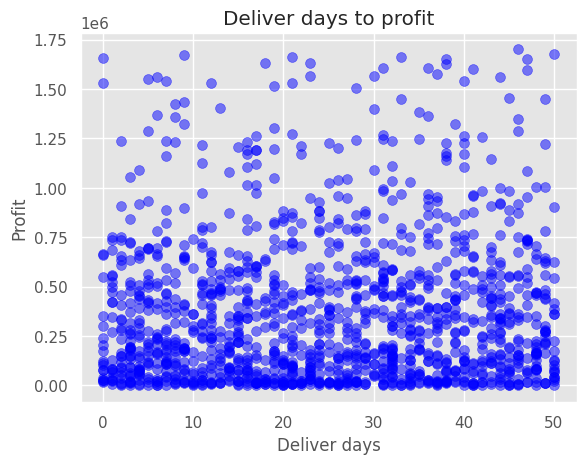

In [ ]:
# Чи залежить прибуток від часу необхідного на відвантаження товару
plt.style.use('ggplot')
plt.scatter(sales_data["deliver"], sales_data["profit"], s = 50, alpha = 0.5, color = "blue")
plt.title("Deliver days to profit")
plt.xlabel("Deliver days")
plt.ylabel("Profit")
plt.show()

*Точки охоплюють весь графік, і не показують ніякої залежності, отже кількість часу на доставку не впливає на прибуток.*

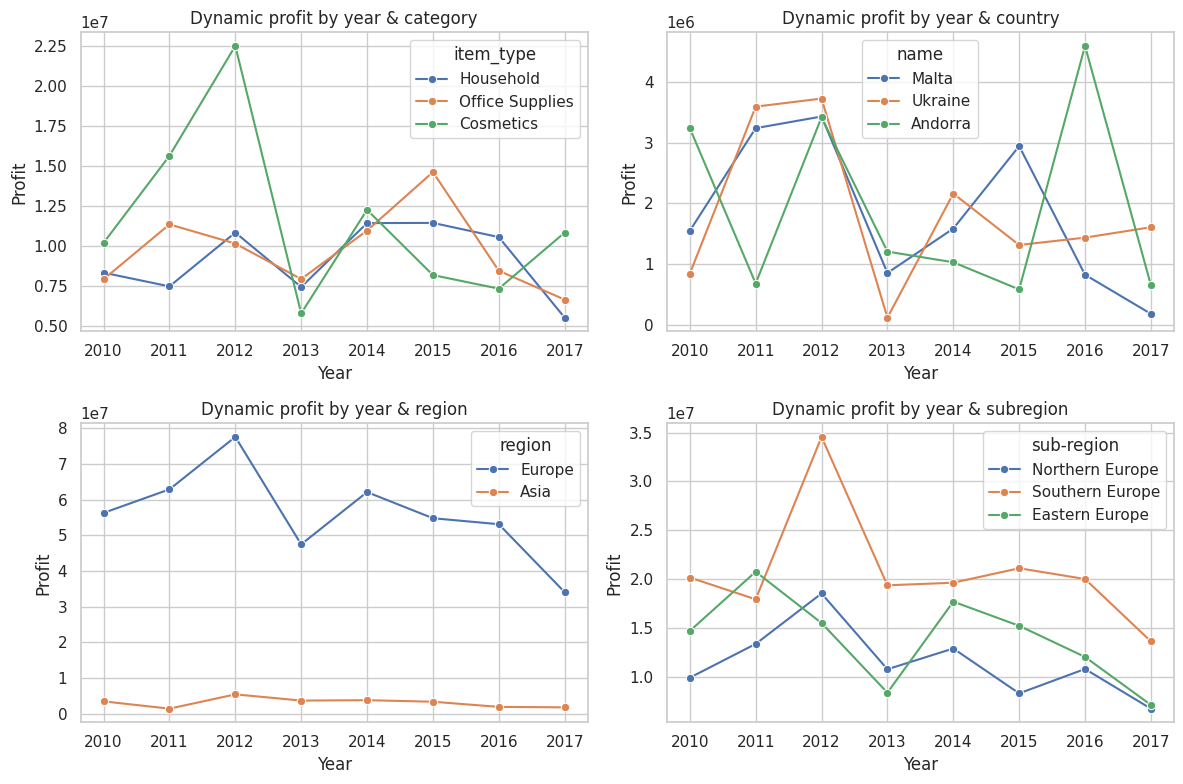

In [ ]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Динаміка продажів по роках у розрізі категорій
# Знаходимо топ 3 категорії по прибутку і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_category = sales_data.groupby("item_type")["profit"].sum().sort_values(ascending = False).head(3).index
top3_df = sales_data[sales_data["item_type"].isin(top3_category)]
sns.lineplot(data = top3_df, x = top3_df["order_date"].dt.year, y = "profit", hue = "item_type", marker = "o", estimator = sum, ax = ax[0, 0], errorbar=None)
ax[0, 0].set_title("Dynamic profit by year & category")
ax[0, 0].set_xlabel("Year")
ax[0, 0].set_ylabel("Profit")

# Динаміка продажів по роках у розрізі країн
# Знаходимо топ 3 країни по прибутку і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_country = sales_data.groupby("name")["profit"].sum().sort_values(ascending = False).head(3).index
top3_cdf = sales_data[sales_data["name"].isin(top3_country)]
sns.lineplot(data = top3_cdf, x = top3_cdf["order_date"].dt.year, y = "profit", hue = "name", marker = "o", estimator = sum, ax = ax[0, 1], errorbar=None)
ax[0, 1].set_title("Dynamic profit by year & country")
ax[0, 1].set_xlabel("Year")
ax[0, 1].set_ylabel("Profit")

# Динаміка продажів по роках у розрізі регіонів
sns.lineplot(data = sales_data, x = sales_data["order_date"].dt.year, y = "profit", hue = "region", marker = "o", estimator = sum, ax = ax[1, 0], errorbar=None)
ax[1, 0].set_title("Dynamic profit by year & region")
ax[1, 0].set_xlabel("Year")
ax[1, 0].set_ylabel("Profit")

# Динаміка продажів по роках у розрізі країн
# Знаходимо топ 3 субрегіони по прибутку і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_subregions = sales_data.groupby("sub-region")["profit"].sum().sort_values(ascending = False).head(3).index
top3_sdf = sales_data[sales_data["sub-region"].isin(top3_subregions)]
sns.lineplot(data = top3_sdf, x = top3_sdf["order_date"].dt.year, y = "profit", hue = "sub-region", marker = "o", estimator = sum, ax = ax[1, 1], errorbar=None)
ax[1, 1].set_title("Dynamic profit by year & subregion")
ax[1, 1].set_xlabel("Year")
ax[1, 1].set_ylabel("Profit")

plt.tight_layout()
plt.show()

- Для кожної категорії бачимо різні динаміки, можна звернути увагу, що в категорії Cosmetics, яка є топ1 категорією по прибутку в 2012 році дуже сильно зріс прибуток.

- В 2016 році Андора яка є топ1 країною по прибуику також відбувся дуже сильний ріст.

- З європи маємо найбільші прибутки в 2012 році, в Азії також, хоча там графік доволі рівномірний без великих підйомів і падінь.

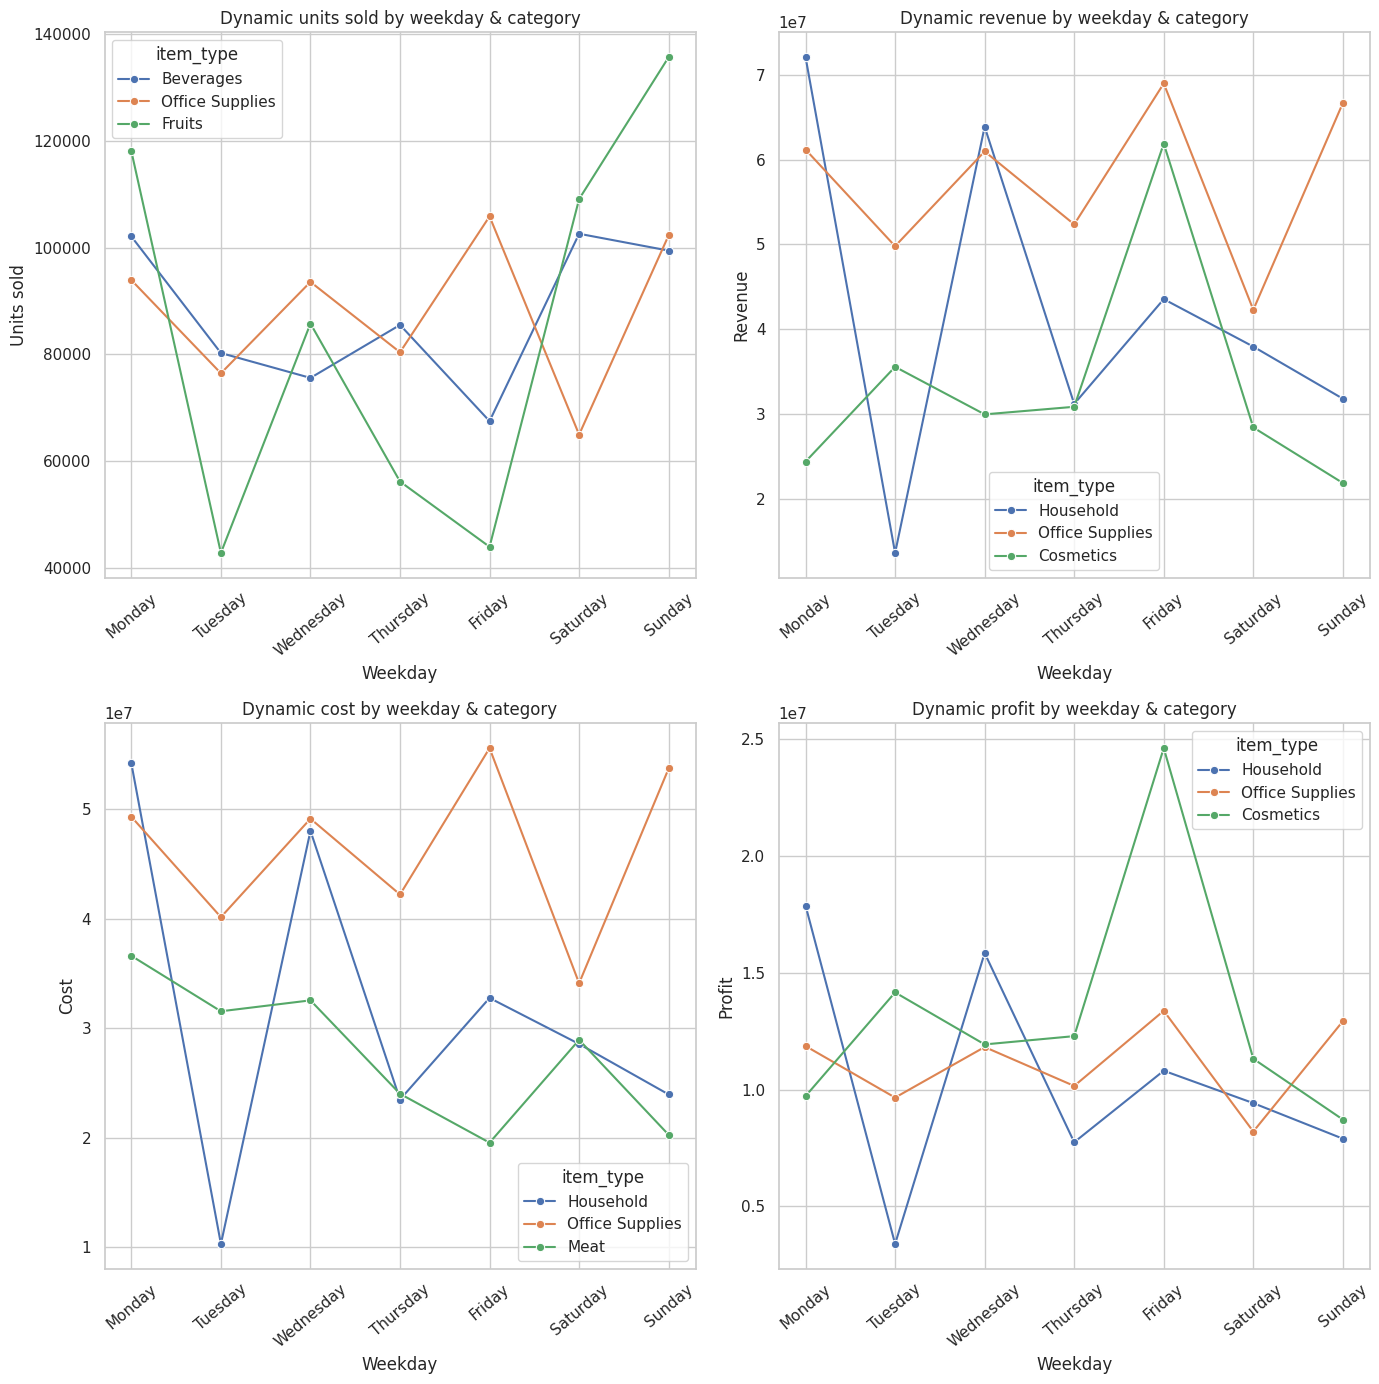

In [ ]:
# Додавання колонки weekday для дня тижня
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_data["weekday"] = pd.Categorical(sales_data["order_date"].dt.day_name(), categories = days_order, ordered = True)
sns.set_theme(style="whitegrid")
# Аналіз продажів товарів за днями тижня
fig, ax = plt.subplots(2, 2, figsize = (14, 14))

# Знаходимо топ 3 категорії по кількості проданих одиниць і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_category_units_sold = sales_data.groupby("item_type")["units_sold"].sum().sort_values(ascending = False).head(3).index
top3_udf = sales_data[sales_data["item_type"].isin(top3_category_units_sold)]

sns.lineplot(data = top3_udf, x = "weekday", y = "units_sold", hue = "item_type", marker = "o", estimator = "sum", errorbar=None, ax = ax[0, 0])
ax[0, 0].set_title("Dynamic units sold by weekday & category")
ax[0, 0].set_xlabel("Weekday")
ax[0, 0].set_ylabel("Units sold")
ax[0, 0].tick_params(axis = "x", rotation = 40)

# Знаходимо топ 3 категорії по revenue і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_category_revenue = sales_data.groupby("item_type")["revenue"].sum().sort_values(ascending = False).head(3).index
top3_rdf = sales_data[sales_data["item_type"].isin(top3_category_revenue)]

sns.lineplot(data = top3_rdf, x = "weekday", y = "revenue", hue = "item_type", marker = "o", estimator = "sum", errorbar=None, ax = ax[0, 1])
ax[0, 1].set_title("Dynamic revenue by weekday & category")
ax[0, 1].set_xlabel("Weekday")
ax[0, 1].set_ylabel("Revenue")
ax[0, 1].tick_params(axis = "x", rotation = 40)

# Знаходимо топ 3 категорії по cost і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_category_cost = sales_data.groupby("item_type")["cost"].sum().sort_values(ascending = False).head(3).index
top3_cdf = sales_data[sales_data["item_type"].isin(top3_category_cost)]

sns.lineplot(data = top3_cdf, x = "weekday", y = "cost", hue = "item_type", marker = "o", estimator = "sum", errorbar=None, ax = ax[1, 0])
ax[1, 0].set_title("Dynamic cost by weekday & category")
ax[1, 0].set_xlabel("Weekday")
ax[1, 0].set_ylabel("Cost")
ax[1, 0].tick_params(axis = "x", rotation = 40)

# Знаходимо топ 3 категорії по profit і робимо візуалізацію з ними, щоб не перенасичувати графік
top3_category_profit = sales_data.groupby("item_type")["profit"].sum().sort_values(ascending = False).head(3).index
top3_pdf = sales_data[sales_data["item_type"].isin(top3_category_profit)]

sns.lineplot(data = top3_pdf, x = "weekday", y = "profit", hue = "item_type", marker = "o", estimator = "sum", errorbar=None, ax = ax[1, 1])
ax[1, 1].set_title("Dynamic profit by weekday & category")
ax[1, 1].set_xlabel("Weekday")
ax[1, 1].set_ylabel("Profit")
ax[1, 1].tick_params(axis = "x", rotation = 40)



plt.tight_layout()
plt.show()

- Cosmetics (топ1 категорія по прибутку) у графіках мала найвищі показники в П'ятницю.

- Clothes продавав найбільшу кількість одиниць в Вівторок і найменшу в наступний ж день - Середу.

- HouseHold приносив найбільший прибуток у Вівторок.

- Багато показників загалом після різкого підйому в якийсь день тижня на наступний день так само різко падають.

# Висновки
- Всього було близько 1328 замовлень і близько 6,576,524 було продано одиниць товару.
- За період 2010 по 2017 рік загальний прибуток склав $501,434,459
- 44 охоплені країни.
- Найвищий прибуток в 2012 році.
- Майже весь прибуток від Європи (найбільше зі східної) Азія складає дуже малу частину.
- Найдовший час доставки - 50 днів, загалом цей час ніяк не впливає на прибуток.
- Найприбутковіша категорія - Cosmetics, а найбільша кількість проданих одиниць в Clothes та Office Supplies. Також найбільший виторг займає Office Supplies, але оскільки компанія і вклала в цю категорію велику кількість грошей (дещо меншу за Cosmetics) то таким чином ця категорія не стала топ1 по профіту.
- Найприбутковіша країна - Андора, хоч і загалом найпопулярніші країни по прибутку не сильно відстають від один одного.
- Покупки Online і Offline практично рівномірні по частоті та інших показниках.

*Компанії варто звернути увагу на ринок Азії — він зараз майже не охоплений, але має потенціал. Cosmetics — найприбутковіша категорія з відносно невисокими витратами, тому саме з нею варто далі активно працювати. Після піку 2012 року продажі, зменшились, що свідчить, що компанії можливо варто задуматись про нову стратегію.*